# ResNet-50 vs Swin Transformer — Matched Experiment

**Goal:** Train a pretrained ResNet-50 using the **exact same setup** as the Swin notebook (`VIT-Swin.ipynb`), so the only variable is the architecture itself.

Every hyperparameter, data split, augmentation pipeline, and evaluation metric is identical to the Swin experiment.

In [1]:
# ====== IMPORTS & DEVICE SETUP ======
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
import tqdm
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, f1_score,
    matthews_corrcoef, cohen_kappa_score, precision_recall_fscore_support,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from collections import Counter
import monai.transforms as mt
import pandas as pd
import copy
import warnings
warnings.filterwarnings('ignore')

torch.backends.cudnn.benchmark = True
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device | PyTorch {torch.__version__}")

/home/paris/miniconda3/envs/jupyter/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda device | PyTorch 2.9.0+rocm6.4


## 1. Data Loading — Same Split as Swin

In [2]:
# ====== DATASET — SAME SPLIT AS SWIN ======
dataset = load_dataset('Falah/Alzheimer_MRI', split='train')
NUM_CLASSES = 4
LABELS = {0: "Mild Demented", 1: "Moderate Demented", 2: "Non Demented", 3: "Very Mild Demented"}
CLASS_NAMES = list(LABELS.values())
print(f"Loaded {len(dataset)} samples")

all_labels = [ex['label'] for ex in dataset]

# SAME split as Swin notebook (VIT-Swin.ipynb cell 10): 80/20 stratified, random_state=42
train_idx, val_idx = train_test_split(
    np.arange(len(dataset)), test_size=0.2, stratify=all_labels, random_state=42
)

train_labels = [dataset[idx]['label'] for idx in train_idx]
class_counts = Counter(train_labels)

print("\nTraining set distribution:")
for k in sorted(class_counts):
    print(f"  {LABELS[k]}: {class_counts[k]} ({100*class_counts[k]/len(train_labels):.1f}%)")

# Class weights — inverse frequency, same formula as Swin notebook
total_train = len(train_labels)
class_weights = torch.tensor(
    [total_train / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)],
    dtype=torch.float32
).to(device)
print(f"\nClass weights: {class_weights.cpu().numpy().round(3)}")
print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")

Loaded 5120 samples

Training set distribution:
  Mild Demented: 579 (14.1%)
  Moderate Demented: 39 (1.0%)
  Non Demented: 2053 (50.1%)
  Very Mild Demented: 1425 (34.8%)

Class weights: [ 1.769 26.256  0.499  0.719]
Train: 4096 | Val: 1024


## 2. Dataset Class — Same Augmentation as Swin

MONAI augmentation pipeline is identical to `VIT-Swin.ipynb` cell 9.

**Minority threshold = 0.15**: classes with < 15% of training samples get aggressive augmentation (Mild Demented ~14%, Moderate Demented ~1%). Classes above 15% get standard augmentation.

**ImageNet normalization** (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`): these are the per-channel statistics of the ImageNet-1K dataset. Since ResNet-50 was pretrained on ImageNet with this normalization, the input must match. The Swin notebook achieves the same via `AutoImageProcessor.from_pretrained()` which bakes in equivalent normalization.

In [3]:
# ====== DATASET CLASS ======
# ImageNet-1K dataset statistics — required for pretrained model normalization.
# These are the per-channel mean and std computed over the full 1.28M image ImageNet dataset.
# Both ResNet (torchvision) and Swin (HuggingFace AutoImageProcessor) normalize with these values.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Minority threshold: classes with < 15% of training samples get aggressive augmentation.
# Same value as VIT-Swin.ipynb cell 9.
MINORITY_THRESHOLD = 0.15

class AlzMRIDataset(Dataset):
    """
    Grayscale MRI -> 224x224 RGB with MONAI augmentation.
    Augmentation pipeline matches VIT-Swin.ipynb exactly.
    """
    def __init__(self, hf_dataset, indices, class_counts=None,
                 augment=True, minority_threshold=MINORITY_THRESHOLD):
        self.data = hf_dataset
        self.indices = indices
        self.augment = augment

        # Identify minority classes — same logic as Swin notebook
        self.minority_classes = set()
        if class_counts:
            total = sum(class_counts.values())
            self.minority_classes = {
                c for c, count in class_counts.items()
                if count / total < minority_threshold
            }
            print(f"Minority classes (< {minority_threshold*100:.0f}%): "
                  f"{[LABELS[c] for c in sorted(self.minority_classes)]}")

        # MONAI pipelines — identical to VIT-Swin.ipynb cell 9
        self.monai_minority = mt.Compose([
            mt.RandFlip(prob=0.5, spatial_axis=1),
            mt.RandRotate(prob=0.8, range_x=0.35),       # ~20 degrees
            mt.RandZoom(prob=0.5, min_zoom=0.85, max_zoom=1.15),
            mt.RandGaussianNoise(prob=0.3, mean=0.0, std=0.05),
            mt.RandAdjustContrast(prob=0.3, gamma=(0.8, 1.2)),
            mt.RandGaussianSmooth(prob=0.2, sigma_x=(0.25, 0.75)),
            mt.RandShiftIntensity(prob=0.3, offsets=0.1),
        ])
        self.monai_standard = mt.Compose([
            mt.RandFlip(prob=0.5, spatial_axis=1),
            mt.RandRotate(prob=0.5, range_x=0.26),       # ~15 degrees
            mt.RandZoom(prob=0.3, min_zoom=0.9, max_zoom=1.1),
        ])

        self.normalize = T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        img = np.array(self.data[real_idx]['image'], dtype=np.float32) / 255.0
        label = self.data[real_idx]['label']

        img_t = torch.tensor(img).unsqueeze(0)  # (1, H, W)

        if self.augment:
            if label in self.minority_classes:
                img_t = self.monai_minority(img_t)
            else:
                img_t = self.monai_standard(img_t)

        img_t = torch.clamp(img_t, 0, 1)

        # Resize to 224x224 (same as Swin input)
        img_t = F.interpolate(
            img_t.unsqueeze(0), size=224, mode='bilinear', align_corners=False
        ).squeeze(0)

        # Grayscale -> RGB: repeat single channel 3 times
        img_rgb = img_t.repeat(3, 1, 1)

        # ImageNet normalization
        img_rgb = self.normalize(img_rgb)

        return img_rgb, torch.tensor(label, dtype=torch.long)


# Create datasets
train_dataset = AlzMRIDataset(dataset, train_idx, class_counts, augment=True)
val_dataset = AlzMRIDataset(dataset, val_idx, augment=False)

print(f"\nTrain dataset: {len(train_dataset)} | Val dataset: {len(val_dataset)}")

Minority classes (< 15%): ['Mild Demented', 'Moderate Demented']

Train dataset: 4096 | Val dataset: 1024


In [4]:
# ====== DATALOADERS ======
BATCH_SIZE = 32

# Balanced sampler — draws with replacement so each class appears equally often per epoch.
# Weights are computed from TRAINING set class counts (not full dataset).
# replacement=True is required because minority classes have fewer samples than we need to draw.
# Same approach as VIT-Swin.ipynb.
sample_weights = [1.0 / class_counts[all_labels[i]] for i in train_idx]
balanced_sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

pin = (device == 'cuda')
train_loader = DataLoader(train_dataset, BATCH_SIZE, sampler=balanced_sampler,
                          pin_memory=pin, num_workers=2)
val_loader = DataLoader(val_dataset, BATCH_SIZE, pin_memory=pin, num_workers=2)

print(f"Batch size: {BATCH_SIZE}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Batch size: 32
Train batches: 128 | Val batches: 32


## 3. ResNet-50 Model Setup

**Architecture:** ResNet-50 from torchvision, pretrained on ImageNet-1K (~25.6M params).

The model structure is: `conv1 → bn1 → relu → maxpool → layer1 (216K) → layer2 (1.2M) → layer3 (7.1M) → layer4 (15.0M) → avgpool → fc`

We replace only the final `fc` layer: `Linear(2048 → 1000)` becomes `Linear(2048 → 4)`. Everything else (the entire feature extraction backbone) keeps its ImageNet-pretrained weights.

**Freeze ratio = 60%**: same as Swin notebook (`setup_fine_tuning(model, freeze_ratio=0.6)`). The first 60% of parameters are frozen; the later layers + classifier head are trainable.

In [5]:
# ====== RESNET-50 MODEL ======
print("Loading ResNet-50 (ImageNet pretrained)...")
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Replace final FC for 4 classes
# Original: Linear(2048 -> 1000) for ImageNet
# New:      Linear(2048 -> 4) for Alzheimer classification
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)  # 2048 -> 4

resnet = resnet.to(device)

# Freeze 60% of parameters — same ratio as Swin notebook (freeze_ratio=0.6)
all_params = list(resnet.named_parameters())
freeze_until = int(len(all_params) * 0.6)
for i, (name, param) in enumerate(all_params):
    param.requires_grad = (i >= freeze_until)

# Always train the FC head (same as Swin always trains classifier)
for param in resnet.fc.parameters():
    param.requires_grad = True

total_p = sum(p.numel() for p in resnet.parameters())
trainable_p = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
print(f"Total params: {total_p:,}")
print(f"Trainable: {trainable_p:,} ({100*trainable_p/total_p:.1f}%)")
print(f"Frozen: {total_p - trainable_p:,} ({100*(total_p - trainable_p)/total_p:.1f}%)")

Loading ResNet-50 (ImageNet pretrained)...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/paris/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|███████████████████████████████████████████| 97.8M/97.8M [00:08<00:00, 12.6MB/s]


Total params: 23,516,228
Trainable: 19,179,012 (81.6%)
Frozen: 4,337,216 (18.4%)


## 4. Training Configuration — Mirrors Swin Exactly

Every hyperparameter below is copied from `VIT-Swin.ipynb` cell 17.

| Parameter | Value | Swin Reference |
|-----------|-------|----------------|
| Optimizer | AdamW | Same |
| LR (backbone) | 2e-5 | `LEARNING_RATE = 2e-5` |
| LR (head) | 2e-4 (10x backbone) | `LEARNING_RATE * 10` |
| Weight decay | 0.01 | `WEIGHT_DECAY = 0.01` |
| Loss | CrossEntropyLoss (class-weighted) | Same |
| Scheduler | ReduceLROnPlateau(patience=2, factor=0.5) | Same |
| Epochs | 15 | `EPOCHS = 15` |
| Early stopping | patience=5 on val accuracy | `EARLY_STOPPING_PATIENCE = 5` |
| Gradient clipping | max_norm=1.0 | `clip_grad_norm_(..., max_norm=1.0)` |

In [6]:
# ====== TRAINING CONFIG — MATCHES SWIN EXACTLY ======
LEARNING_RATE = 2e-5     # Same as VIT-Swin.ipynb
WEIGHT_DECAY = 0.01      # Same as VIT-Swin.ipynb
EPOCHS = 15              # Same as VIT-Swin.ipynb
EARLY_STOPPING_PATIENCE = 5  # Same as VIT-Swin.ipynb

# Differential LR: backbone 2e-5, head 2e-4 (10x) — same as Swin
backbone_params = [p for n, p in resnet.named_parameters()
                   if 'fc' not in n and p.requires_grad]
head_params = list(resnet.fc.parameters())

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': LEARNING_RATE},
    {'params': head_params, 'lr': LEARNING_RATE * 10},
], weight_decay=WEIGHT_DECAY)

criterion = nn.CrossEntropyLoss(weight=class_weights)

scheduler = lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

print("Training Configuration (mirrors Swin):")
print(f"  LR backbone:    {LEARNING_RATE}")
print(f"  LR head:        {LEARNING_RATE * 10}")
print(f"  Weight decay:   {WEIGHT_DECAY}")
print(f"  Epochs:         {EPOCHS}")
print(f"  Early stopping: {EARLY_STOPPING_PATIENCE}")
print(f"  Grad clipping:  1.0")

Training Configuration (mirrors Swin):
  LR backbone:    2e-05
  LR head:        0.0002
  Weight decay:   0.01
  Epochs:         15
  Early stopping: 5
  Grad clipping:  1.0


## 5. Training

In [7]:
# ====== TRAINING LOOP — SAME STRUCTURE AS SWIN ======
def train_resnet(model, train_loader, val_loader, optimizer, criterion,
                 scheduler=None, epochs=15, early_stopping_patience=5):
    """
    Training loop — same structure as train_swin_model in VIT-Swin.ipynb cell 15.
    Early stopping on validation accuracy. Gradient clipping at max_norm=1.0.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        pbar = tqdm.tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]', leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            train_correct += (out.argmax(1) == labels).sum().item()
            train_total += labels.size(0)
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(train_correct / train_total)

        # --- Validate ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in tqdm.tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False):
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = criterion(out, labels)
                val_loss += loss.item()
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step(avg_val_loss)

        # Early stopping on val accuracy — same as Swin
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            marker = " *best*"
        else:
            patience_counter += 1
            marker = ""

        print(f"Epoch {epoch+1}: Train Acc={history['train_acc'][-1]:.4f} | "
              f"Val Acc={val_acc:.4f} | Val Loss={avg_val_loss:.4f}{marker}")

        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    if best_state:
        model.load_state_dict(best_state)
    return model, history


# Run training
print("=" * 60)
print("Training ResNet-50")
print("=" * 60)

resnet, history = train_resnet(
    resnet, train_loader, val_loader,
    optimizer, criterion, scheduler,
    epochs=EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE
)

Training ResNet-50


Epoch 1: Train Acc=0.2563 | Val Acc=0.0098 | Val Loss=1.5662 *best*


Epoch 2: Train Acc=0.2590 | Val Acc=0.1768 | Val Loss=1.2449 *best*


Epoch 3: Train Acc=0.4658 | Val Acc=0.3496 | Val Loss=1.0786 *best*


Epoch 4: Train Acc=0.5701 | Val Acc=0.3525 | Val Loss=0.9949 *best*


...

Epoch 11: Train Acc=0.7471 | Val Acc=0.5820 | Val Loss=0.7569


Epoch 12: Train Acc=0.7673 | Val Acc=0.5762 | Val Loss=0.7749


Epoch 13: Train Acc=0.7744 | Val Acc=0.6025 | Val Loss=0.7739 *best*


Epoch 14: Train Acc=0.7805 | Val Acc=0.5938 | Val Loss=0.7249


Epoch 15: Train Acc=0.7871 | Val Acc=0.6045 | Val Loss=0.7678 *best*


## 6. Evaluation — Same Metrics as Swin

`compute_all_metrics()` is identical to `VIT-Swin.ipynb` cell 14.

Metrics computed:
- **Overall:** accuracy, balanced accuracy, specificity (macro), F1 (macro + weighted), MCC, Cohen's kappa, ROC-AUC (OvR macro)
- **Per-class:** precision, recall, specificity, F1, support

In [8]:
# ====== METRICS — SAME FUNCTION AS SWIN NOTEBOOK (cell 14) ======
def compute_all_metrics(y_true, y_pred, y_proba=None, class_names=None):
    """Compute comprehensive classification metrics. Identical to VIT-Swin.ipynb."""
    metrics = {}
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)
    metrics['f1_macro'] = f1_score(y_true, y_pred, average='macro')
    metrics['f1_weighted'] = f1_score(y_true, y_pred, average='weighted')
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)
    metrics['kappa'] = cohen_kappa_score(y_true, y_pred)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )
    if class_names is None:
        class_names = [f'Class_{i}' for i in range(len(precision))]

    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    metrics['per_class'] = {}
    specificity_scores = []

    for i, name in enumerate(class_names):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - tp - fn - fp
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        specificity_scores.append(spec)
        metrics['per_class'][name] = {
            'precision': precision[i], 'recall': recall[i],
            'specificity': spec, 'f1': f1[i], 'support': int(support[i])
        }

    metrics['specificity_macro'] = float(np.mean(specificity_scores))
    if y_proba is not None:
        try:
            metrics['roc_auc_ovr'] = roc_auc_score(
                y_true, y_proba, multi_class='ovr', average='macro'
            )
        except Exception:
            metrics['roc_auc_ovr'] = None
    return metrics


def predict_with_proba(model, loader):
    """Run inference, return (predictions, labels, probabilities). Same as Swin notebook."""
    model.eval()
    preds, labels, probas = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out = model(imgs.to(device))
            probs = F.softmax(out, dim=1)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probas.extend(probs.cpu().numpy())
    return np.array(preds), np.array(labels), np.array(probas)


# Evaluate on validation set — same as Swin
preds, labels, probas = predict_with_proba(resnet, val_loader)
metrics = compute_all_metrics(labels, preds, probas, CLASS_NAMES)

print("=" * 60)
print("RESNET-50 — EVALUATION RESULTS")
print("=" * 60)
for k in ['accuracy', 'balanced_accuracy', 'specificity_macro',
          'f1_macro', 'f1_weighted', 'mcc', 'kappa', 'roc_auc_ovr']:
    val = metrics.get(k)
    if val is not None:
        print(f"  {k:25s}: {val:.4f}")
    else:
        print(f"  {k:25s}: N/A")

print("\nPer-class:")
for cls in CLASS_NAMES:
    pc = metrics['per_class'][cls]
    print(f"  {cls:22s}  P={pc['precision']:.4f}  R={pc['recall']:.4f}  "
          f"Sp={pc['specificity']:.4f}  F1={pc['f1']:.4f}  n={pc['support']}")

RESNET-50 — EVALUATION RESULTS
  accuracy                 : 0.6045
  balanced_accuracy        : 0.6767
  specificity_macro        : 0.8468
  f1_macro                 : 0.6639
  f1_weighted              : 0.6055
  mcc                      : 0.4034
  kappa                    : 0.3704
  roc_auc_ovr              : 0.8538

Per-class:
  Mild Demented           P=0.5851  R=0.3793  Sp=0.9556  F1=0.4603  n=145
  Moderate Demented       P=0.9091  R=1.0000  Sp=0.9990  F1=0.9524  n=10
  Non Demented            P=0.8526  R=0.5185  Sp=0.9100  F1=0.6448  n=513
  Very Mild Demented      P=0.4745  R=0.8090  Sp=0.5225  F1=0.5981  n=356


In [9]:
# ====== SAVE CHECKPOINT — SAME FORMAT AS SWIN ======
torch.save({
    'model_state_dict': resnet.state_dict(),
    'metrics': metrics,
    'history': history,
    'labels': LABELS,
}, 'models/resnet50_alzheimer.pt')
print("Saved to models/resnet50_alzheimer.pt")

Saved to models/resnet50_alzheimer.pt


## 7. Head-to-Head Comparison: ResNet-50 vs Swin Transformer

In [10]:
# ====== SIDE-BY-SIDE COMPARISON ======
swin_ckpt = torch.load('models/swin_alzheimer_classifier.pt',
                        map_location='cpu', weights_only=False)
swin_metrics = swin_ckpt['metrics']

print("=" * 70)
print("HEAD-TO-HEAD: ResNet-50 vs Swin Transformer")
print("(Same data, same split, same augmentation, same hyperparameters)")
print("=" * 70)

header = f"{'Metric':<25} {'ResNet-50':>10} {'Swin':>10} {'Delta':>10}"
print(header)
print("-" * len(header))
for k in ['accuracy', 'balanced_accuracy', 'specificity_macro',
          'f1_macro', 'f1_weighted', 'mcc', 'kappa', 'roc_auc_ovr']:
    r = metrics.get(k, 0) or 0
    s = swin_metrics.get(k, 0) or 0
    delta = r - s
    sign = "+" if delta >= 0 else ""
    print(f"  {k:<23} {r:>10.4f} {s:>10.4f} {sign}{delta:>9.4f}")

print("\nPer-class F1:")
for cls in CLASS_NAMES:
    r = metrics['per_class'][cls]['f1']
    s = swin_metrics['per_class'][cls]['f1']
    delta = r - s
    sign = "+" if delta >= 0 else ""
    print(f"  {cls:<22} {r:>10.4f} {s:>10.4f} {sign}{delta:>9.4f}")

HEAD-TO-HEAD: ResNet-50 vs Swin Transformer
(Same data, same split, same augmentation, same hyperparameters)
Metric                     ResNet-50       Swin      Delta
----------------------------------------------------------
  accuracy                    0.6045     0.8760   -0.2715
  balanced_accuracy           0.6767     0.9044   -0.2277
  specificity_macro           0.8468     0.0000 +   0.8468
  f1_macro                    0.6639     0.8916   -0.2277
  f1_weighted                 0.6055     0.8768   -0.2713
  mcc                         0.4034     0.7996   -0.3962
  kappa                       0.3704     0.7977   -0.4273
  roc_auc_ovr                 0.8538     0.9773   -0.1236

Per-class F1:
  Mild Demented              0.4603     0.8671   -0.4069
  Moderate Demented          0.9524     0.9524 +   0.0000
  Non Demented               0.6448     0.8959   -0.2510
  Very Mild Demented         0.5981     0.8511   -0.2529


## 8. Visualizations

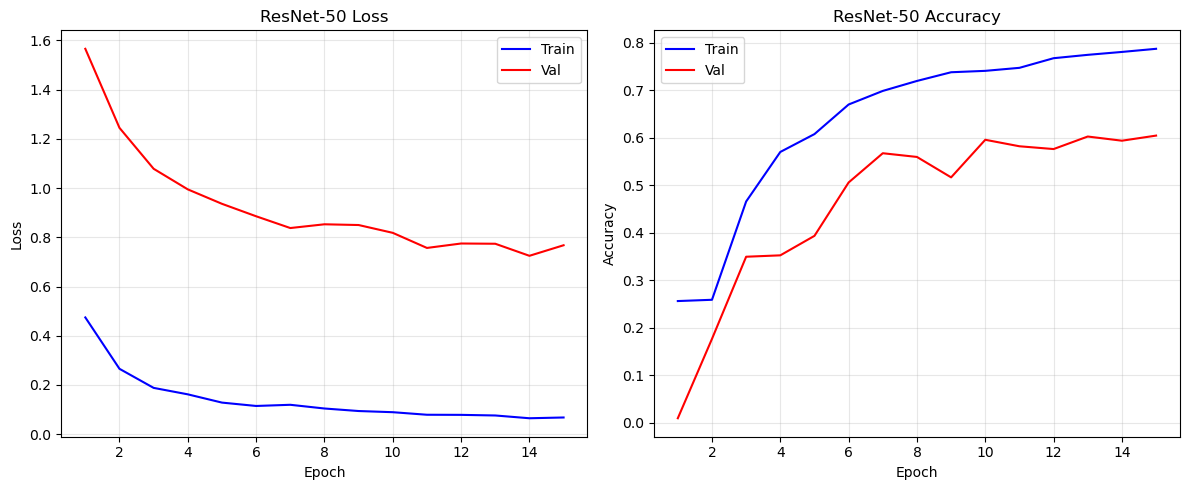

Saved resnet50_training_curves.png


In [11]:
# ====== TRAINING CURVES ======
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

epochs_range = range(1, len(history['train_loss']) + 1)
ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train')
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('ResNet-50 Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train')
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('ResNet-50 Accuracy')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved resnet50_training_curves.png")

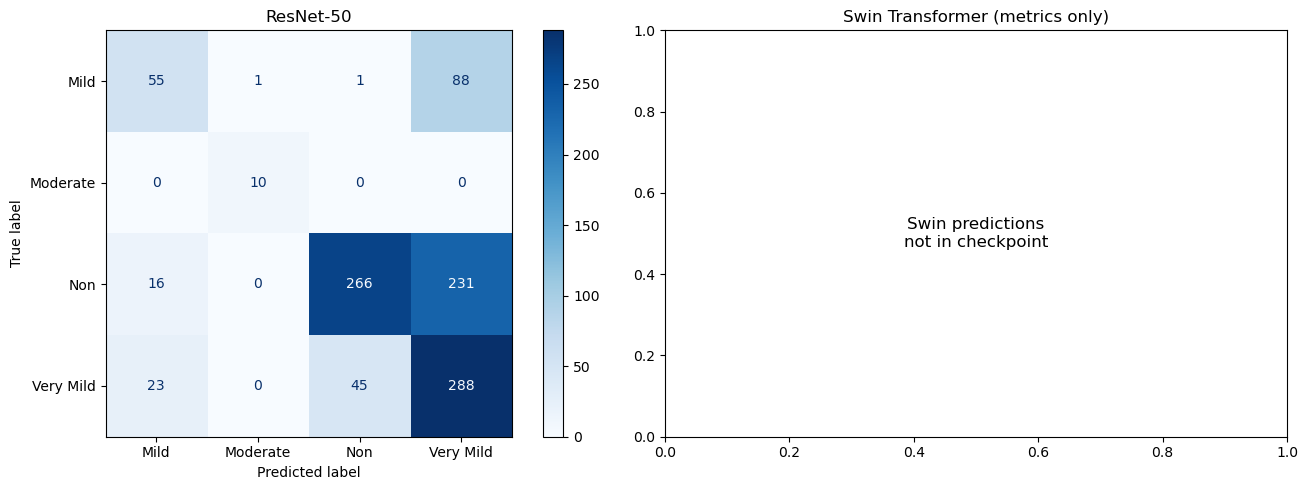

Saved resnet50_vs_swin_confusion.png


In [12]:
# ====== CONFUSION MATRICES SIDE BY SIDE ======
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ResNet-50
cm_resnet = confusion_matrix(labels, preds)
short_names = [n.replace(" Demented", "").replace("Non ", "Non-") for n in CLASS_NAMES]
ConfusionMatrixDisplay(cm_resnet, display_labels=short_names).plot(ax=ax1, cmap='Blues', values_format='d')
ax1.set_title('ResNet-50')

# Swin (from checkpoint)
swin_preds = swin_ckpt.get('predictions')
if swin_preds is not None:
    swin_labels = swin_ckpt.get('true_labels', swin_ckpt.get('labels'))
    if isinstance(swin_labels, dict):
        # labels is the LABELS dict, not predictions — skip
        ax2.text(0.5, 0.5, 'Swin predictions\nnot in checkpoint', ha='center', va='center', fontsize=12)
        ax2.set_title('Swin Transformer (metrics only)')
    else:
        cm_swin = confusion_matrix(swin_labels, swin_preds)
        ConfusionMatrixDisplay(cm_swin, display_labels=short_names).plot(ax=ax2, cmap='Oranges', values_format='d')
        ax2.set_title('Swin Transformer')
else:
    ax2.text(0.5, 0.5, 'Swin predictions\nnot in checkpoint', ha='center', va='center', fontsize=12)
    ax2.set_title('Swin Transformer (metrics only)')

plt.tight_layout()
plt.savefig('resnet50_vs_swin_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved resnet50_vs_swin_confusion.png")

## 9. Grad-CAM Visualization

Generate class-targeted Grad-CAM maps from the final ResNet stage (`layer4[-1]`). The heatmaps use the same `jet` colormap, fixed `[0, 1]` normalization, overlay alpha, validation samples, and labeled colorbar as the Swin notebook, making the two models directly comparable.

In [ ]:
from scripts.gradcam_utils import (
    GradCAM,
    first_sample_positions_per_class,
    plot_gradcam_rows,
)

gradcam_samples = first_sample_positions_per_class(
    dataset, val_idx, NUM_CLASSES
)
gradcam_images = [
    np.asarray(dataset[dataset_index]['image'].convert('L'), dtype=np.float32) / 255.0
    for _position, dataset_index, _class_id in gradcam_samples
]
gradcam_true_classes = [class_id for _position, _dataset_index, class_id in gradcam_samples]

resnet_gradcam_results = []
with GradCAM(resnet, resnet.layer4[-1]) as gradcam:
    for validation_position, _dataset_index, _class_id in gradcam_samples:
        input_tensor, _label = val_dataset[validation_position]
        resnet_gradcam_results.append(
            gradcam(input_tensor.unsqueeze(0).to(device))
        )

plot_gradcam_rows(
    gradcam_images,
    resnet_gradcam_results,
    gradcam_true_classes,
    CLASS_NAMES,
    model_name='ResNet-50',
    cmap='jet',
    alpha=0.45,
    output_path='paper/figures/resnet50_gradcam.png',
)
plt.show()
print('Saved paper/figures/resnet50_gradcam.png')

## 10. Export Results

In [13]:
# ====== UPDATE COMPARISON CSV ======
existing_df = pd.read_csv('comparison_results.csv')

row = {
    'Approach': 'ResNet-50 (Pretrained)',
    'Accuracy': metrics['accuracy'],
    'Balanced Accuracy': metrics['balanced_accuracy'],
    'Specificity Macro': metrics['specificity_macro'],
    'F1 Macro': metrics['f1_macro'],
    'F1 Weighted': metrics['f1_weighted'],
    'MCC': metrics['mcc'],
    'Kappa': metrics['kappa'],
    'ROC-AUC OvR Macro': metrics.get('roc_auc_ovr'),
}
for cls in CLASS_NAMES:
    pc = metrics['per_class'][cls]
    row[f'{cls}_Precision'] = pc['precision']
    row[f'{cls}_Recall'] = pc['recall']
    row[f'{cls}_Specificity'] = pc['specificity']
    row[f'{cls}_F1'] = pc['f1']
    row[f'{cls}_Support'] = pc['support']

# Remove any existing ResNet-50 row, then append
existing_df = existing_df[~existing_df['Approach'].astype(str).str.contains('ResNet-50', na=False)]
updated_df = pd.concat([existing_df, pd.DataFrame([row])], ignore_index=True)
updated_df.to_csv('comparison_results.csv', index=False)
print("Updated comparison_results.csv")
print()
summary_cols = ['Approach', 'Accuracy', 'Balanced Accuracy', 'F1 Macro', 'MCC', 'ROC-AUC OvR Macro']
print(updated_df[summary_cols].round(4).to_string(index=False))

Updated comparison_results.csv

              Approach  Accuracy  Balanced Accuracy  F1 Macro    MCC  ROC-AUC OvR Macro
           1. Baseline    0.5312             0.2752    0.2244 0.1406             0.7315
      2. Weighted Loss    0.5010             0.2500    0.1669 0.0000             0.5000
  3. Balanced Sampling    0.4883             0.3189    0.1972 0.1002             0.5988
 4. MONAI Augmentation    0.5986             0.3503    0.3204 0.3189             0.8026
  5. Combined Strategy    0.3477             0.5134    0.2687 0.0758             0.6502
ResNet-50 (Pretrained)    0.6045             0.6767    0.6639 0.4034             0.8538
